In [19]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
from scipy.signal import welch, find_peaks

In [20]:
df = pd.read_csv('data_Manufacturing_Inventory_Data_FRED.csv')
df

,observation_date,MNFCTRIMNSA
0,1992-01-01,375389
1,1992-02-01,378146
2,1992-03-01,377223
3,1992-04-01,379047
4,1992-05-01,380525
...,...,...
390,2024-07-01,862145
391,2024-08-01,861678
392,2024-09-01,855912
393,2024-10-01,858109


In [21]:
len(df['observation_date'].unique())

395

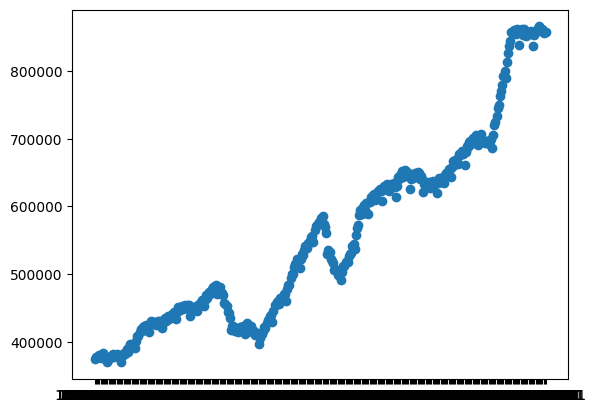

In [22]:
y = df['MNFCTRIMNSA']
x = df['observation_date']
plt.scatter(x,y)


In [23]:
#computing the DFT

signal = np.array(y.values)

dft = np.fft.fft(signal)

len(dft)

395

In [24]:
# Problem 1.c: Compute the Periodogram
# Periodogram: φ̂(ω) = (1/T) * |Σ y(t) e^(-iωt)|²
# DFT normalized by 1/√T: dft_norm[k] = (1/√T) * Σ y(t) e^(-i 2π k t / N)
# So φ̂[k] = |dft_norm[k]|²

T = len(signal)  # T = N = 395
dft_norm = np.fft.fft(signal) / np.sqrt(T)  # DFT normalized by 1/√T
periodogram = np.abs(dft_norm)**2  # φ̂(ω_k) = |dft_norm[k]|²

# Frequency 40/395 cycles/month corresponds to DFT index k=40
k = 40
phi_at_freq = periodogram[k]
print(f"Periodogram at frequency 40/395 cycles/month: {phi_at_freq}")
print(f"Answer (φ̂ × 10^(-9)): {phi_at_freq / 1e9}")

Periodogram at frequency 40/395 cycles/month: 1415104798.1496644
Answer (φ̂ × 10^(-9)): 1.4151047981496645


In [25]:

# Frequency 40/395 cycles/month corresponds to DFT index k=40
k = 79
phi_at_freq = periodogram[k]
print(f"Periodogram at frequency 40/395 cycles/month: {phi_at_freq}")
print(f"Answer (φ̂ × 10^(-9)): {phi_at_freq / 1e9}")

Periodogram at frequency 40/395 cycles/month: 423995648.30823624
Answer (φ̂ × 10^(-9)): 0.4239956483082362


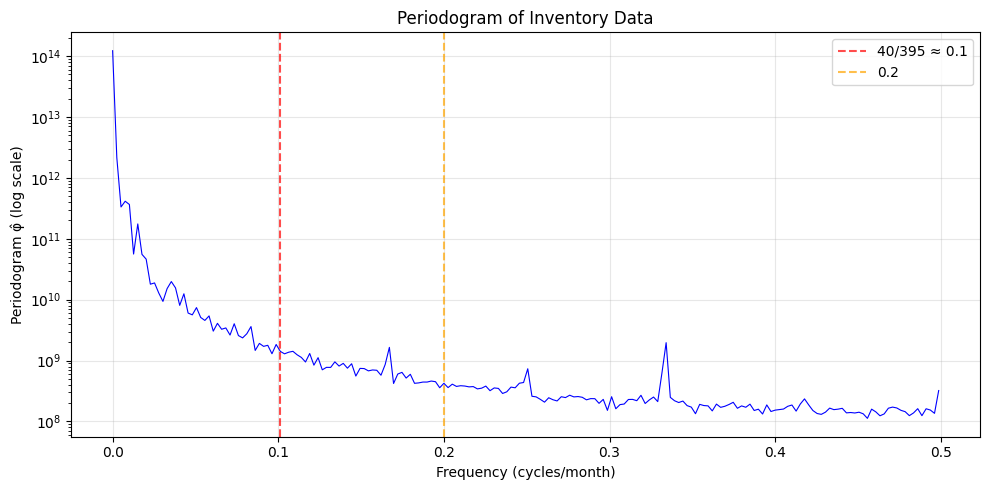

In [26]:
# Plot periodogram vs frequency (log scale)
N = len(signal)
freqs = np.arange(N) / N  # frequency in cycles/month (0 to ~1)
# Plot only positive frequencies up to Nyquist (0 to 0.5)
n_pos = N // 2 + 1
freqs_plot = freqs[:n_pos]
periodogram_plot = periodogram[:n_pos]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(freqs_plot, periodogram_plot, 'b-', linewidth=0.8)
ax.set_xlabel('Frequency (cycles/month)')
ax.set_ylabel('Periodogram φ̂ (log scale)')
ax.set_title('Periodogram of Inventory Data')
ax.grid(True, alpha=0.3)
ax.axvline(40/395, color='r', linestyle='--', alpha=0.7, label='40/395 ≈ 0.1')
ax.axvline(0.2, color='orange', linestyle='--', alpha=0.7, label='0.2')
ax.legend()
plt.tight_layout()
plt.show()

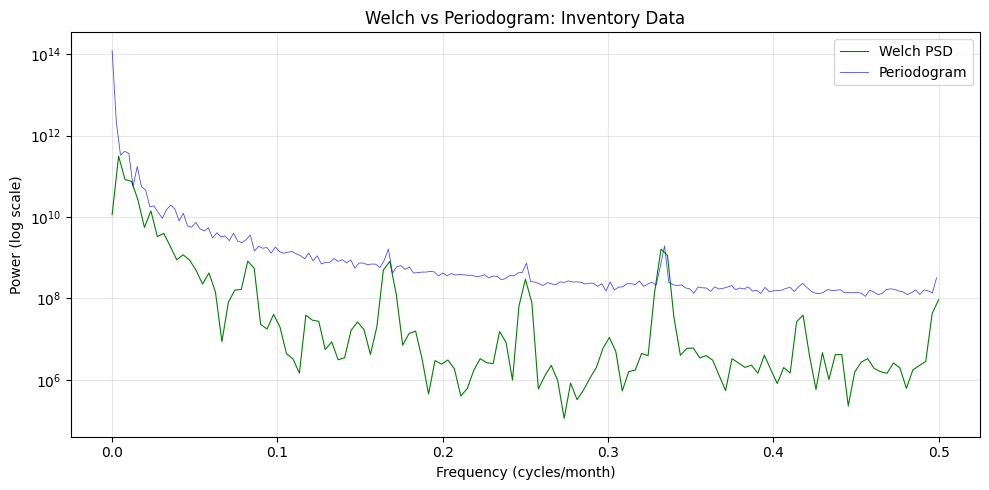

In [27]:
# Welch's method: averaged periodogram over overlapping segments (reduces variance)
fs = 1  # 1 sample per month -> frequencies in cycles/month
freqs_welch, psd_welch = welch(signal, fs=fs)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(freqs_welch, psd_welch, 'g-', linewidth=0.8, label='Welch PSD')
ax.semilogy(freqs_plot, periodogram_plot, 'b-', linewidth=0.6, alpha=0.7, label='Periodogram')
ax.set_xlabel('Frequency (cycles/month)')
ax.set_ylabel('Power (log scale)')
ax.set_title("Welch vs Periodogram: Inventory Data")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

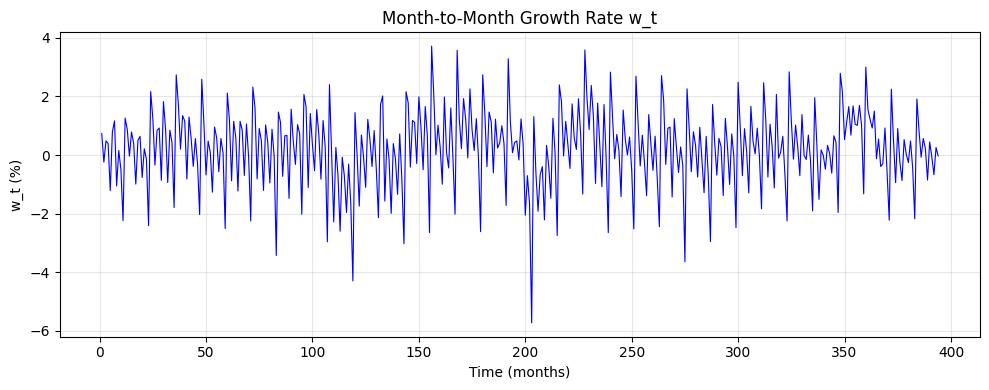

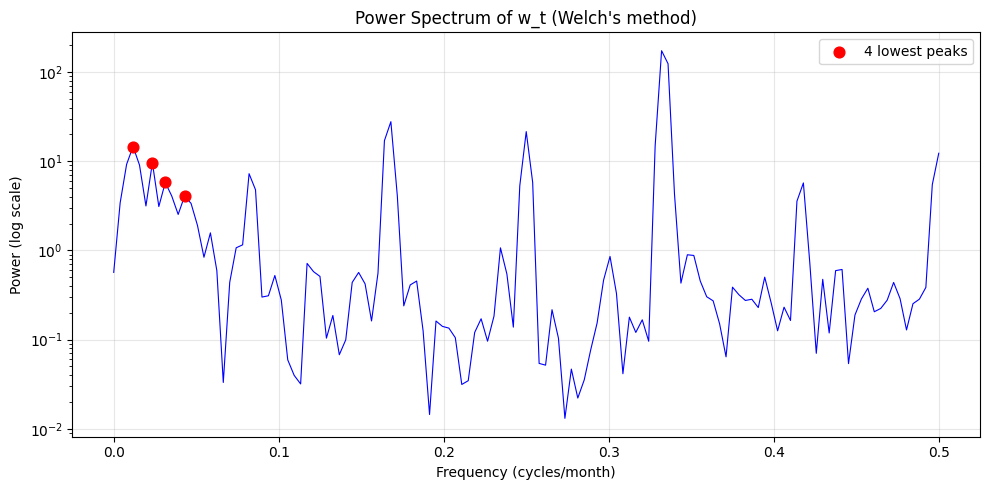

Four lowest-frequency peaks (cycles/month): [0.01171875 0.0234375  0.03125    0.04296875]


In [30]:
# Problem 1.g: Monthly Growth Rate Analysis
# w_t = 100 * [log(y_t) - log(y_{t-1})]
from scipy.signal import find_peaks  # ensure imported if run out of order
y_vals = signal
log_y = np.log(y_vals)
w_t = 100 * (log_y[1:] - log_y[:-1])

# Plot w_t over time
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(w_t) + 1), w_t, 'b-', linewidth=0.8)
ax.set_xlabel('Time (months)')
ax.set_ylabel('w_t (%)')
ax.set_title('Month-to-Month Growth Rate w_t')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Welch's method on w_t (power spectrum, log y-axis)
freqs_w, psd_w = welch(w_t, fs=1)
# "Lowest-frequency" = smallest freq values (leftmost on plot), NOT tallest peaks
peaks, _ = find_peaks(psd_w, prominence=np.percentile(psd_w, 75))
peak_freqs = freqs_w[peaks]
sorted_by_freq = np.argsort(peak_freqs)
lowest_4 = peak_freqs[sorted_by_freq[:4]]  # 4 leftmost peaks

# Alternative: 4 highest-amplitude (tallest) peaks - different result
sorted_by_amp = np.argsort(psd_w[peaks])[::-1]
highest_4_amp = peak_freqs[sorted_by_amp[:4]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(freqs_w, psd_w, 'b-', linewidth=0.8)
peak_indices = peaks[sorted_by_freq[:4]]
ax.scatter(lowest_4, psd_w[peak_indices], color='red', s=60, zorder=5, label='4 lowest peaks')
ax.set_xlabel('Frequency (cycles/month)')
ax.set_ylabel('Power (log scale)')
ax.set_title("Power Spectrum of w_t (Welch's method)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Four lowest-FREQUENCY peaks (leftmost):", np.round(lowest_4, 4))
print("Four highest-AMPLITUDE peaks (tallest):", np.round(highest_4_amp, 4))